# 04 Logistic Regression

Logistic regression is the linear benchmark for the public application feature set.

## Reproducibility note

These notebooks are lightweight narrative companions to the source-controlled pipeline. The canonical workflow lives in src, generated metrics and figures live under reports, and the final selected model is models/xgboost_public.pkl. The protected attribute SEX is excluded from active model training and retained only for fairness diagnostics.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image, Markdown

from src.utils import ROOT_DIR, REPORTS_DIR, MODELS_DIR, load_dataset_auto, load_model
from src.data_preprocessing import TARGET_COL

ROOT = ROOT_DIR
REPORTS = REPORTS_DIR
MODELS = MODELS_DIR
PROCESSED_DATA = ROOT / 'data' / 'processed' / 'uci_taiwan_credit_default_processed.csv'

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def show_image_if_exists(path: Path, width: int = 900):
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing optional image: {path.relative_to(ROOT) if path.is_absolute() else path}')


def load_project_dataset():
    try:
        frame, source = load_dataset_auto()
        return frame, source
    except Exception as exc:
        if PROCESSED_DATA.exists():
            print(f'UCI loader failed; using processed local fallback. Reason: {exc}')
            return pd.read_csv(PROCESSED_DATA), PROCESSED_DATA
        raise

raw_df, DATA_SOURCE = load_project_dataset()
print('Project root:', ROOT)
print('Data source:', DATA_SOURCE)
print('Rows:', f'{len(raw_df):,}')
print('Columns:', raw_df.shape[1])

logistic_metrics = load_json(REPORTS / 'model_validation' / 'logistic_public_model_metrics.json')
xgb_metrics = load_json(REPORTS / 'model_validation' / 'xgboost_public_model_metrics.json')
rows = []
for payload in [logistic_metrics, xgb_metrics]:
    rows.append({'model_name': payload['model_name'], **payload['metrics']})
metrics_df = pd.DataFrame(rows).set_index('model_name')
display(metrics_df)

Project root: D:\PGDBA\Projects\Credit Default Risk\credit-default-xai
Data source: uci:\default_credit_card
Rows: 30,000
Columns: 38


,accuracy,precision,recall,f1,roc_auc,pr_auc
model_name,,,,,,
logistic_public,0.740753,0.437466,0.603617,0.507283,0.752683,0.511075
xgboost_public,0.815228,0.658430,0.341372,0.449628,0.774772,0.541500


## Interpretation

Logistic regression provides a transparent baseline. XGBoost remains the final model because it has stronger ROC-AUC and PR-AUC on the held-out test split.

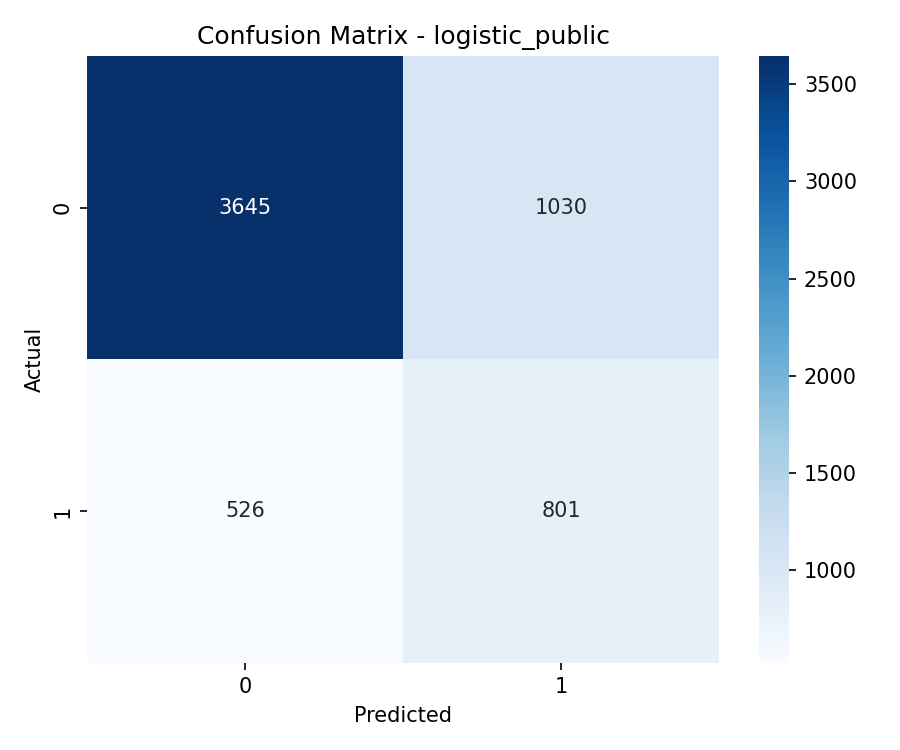

In [2]:
show_image_if_exists(REPORTS / 'figures' / 'logistic_public_confusion_matrix.png', width=700)